# Data Extraction
Connect to the OneDrive and then extract the .DAT files which we want to work with.  
Note that not all of these formats are the same, with some notable exceptions being TAXDATA2021 and Alka_Chopra_ShareFile_TAXDATA2022, which is a download URL.

**Note**: A lot of the code is commented out at the top. This is the code that was originally used to extract the .DAT files from the relevant OneDrive synced folder. Uncomment when running this script the first time and replace COBB_PATH with your relevant path.

In [ ]:
import pandas as pd
import os
import seaborn as sns

DIGEST_PATH = "/Users/tpeng/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Housing and Urban Policy (HUP) Lab - Documents/Data Files/Final Datasets/Cobb/cobb_digest_final.csv"
DATA_PATH = "../../data/cobb"

In [33]:
# 1️ base on Cobb County layout
colspecs = [
    (0,30),   # PARID
    (30,39),  # TRANSNO
    (39,48),  # TRANSDT
    (48,56),  # BOOK
    (56,64),  # PAGE
    (64,73),  # SALEDT
    (73,84),  # PRICE
    (84,85),  # SOURCE
    (85,86),  # SALETYPE
    (86,88),  # SALEVAL
    (88,100)  # FILLER
]

colnames = [
    "PARID", "TRANSNO", "TRANSDT", "BOOK", "PAGE", "SALEDT",
    "PRICE", "SOURCE", "SALETYPE", "SALEVAL", "FILLER"
]

dfs = []

# read .DAT file
for year in ([2000] + list(range(2011, 2020))):
    df = pd.read_fwf(os.path.join(DATA_PATH, f"SALES_{year}.DAT"), colspecs=colspecs, names=colnames)

    # clean data
    # delete filler
    df = df.drop(columns=["FILLER"])
    df['YEAR'] = year

    dfs.append(df)

From 2020 Onwards, the .DAT Format Has || Separators Between Columns

In [34]:
# 2020 onwards layout
colspecs = [
    (0,30),   # PARID
    (31,40),  # TRANSNO
    (41,50),  # TRANSDT
    (51,59),  # BOOK
    (60,68),  # PAGE
    (69,78),  # SALEDT
    (79,90),  # PRICE
    (91,92),  # SOURCE
    (93,94),  # SALETYPE
    (95,97),  # SALEVAL
    (97,100)  # FILLER
]

colnames = [
    "PARID", "TRANSNO", "TRANSDT", "BOOK", "PAGE", "SALEDT",
    "PRICE", "SOURCE", "SALETYPE", "SALEVAL", "FILLER"
]

# read .DAT file
for year in range(2020, 2023):
    df = pd.read_fwf(os.path.join(DATA_PATH, f"SALES_{year}.DAT"), colspecs=colspecs, names=colnames)

    # clean data
    # delete filler
    df = df.drop(columns=["FILLER"])
    df['YEAR'] = year

    dfs.append(df)

In [35]:
final_df = pd.concat(dfs)
orig_rows = final_df.size

# Drop those rows that are duplicates in literally every feature
final_df = final_df.sort_values(by=["YEAR", "SALEDT"])
final_df = final_df.drop_duplicates(subset=['PARID', 'BOOK', 'PAGE', 'SALEDT', 'PRICE'])
new_rows = final_df.size

print(f"Rows dropped: {orig_rows - new_rows}")

Rows dropped: 79540098


In [36]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 857766 entries, 14279 to 604981
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   PARID     857766 non-null  object
 1   TRANSNO   207645 non-null  object
 2   TRANSDT   2449 non-null    object
 3   BOOK      797043 non-null  object
 4   PAGE      797010 non-null  object
 5   SALEDT    857766 non-null  object
 6   PRICE     857766 non-null  int64 
 7   SOURCE    845087 non-null  object
 8   SALETYPE  484482 non-null  object
 9   SALEVAL   807984 non-null  object
 10  YEAR      857766 non-null  int64 
dtypes: int64(2), object(9)
memory usage: 78.5+ MB


# Convert the Price to Numeric, TRANSDT, and SALEDT to Datetime

In [37]:
# Confirm whether price can be successfully converted into numeric with no issues
numeric_price = pd.to_numeric(final_df.PRICE, errors="coerce")
price_errors = numeric_price.isnull()
price_errors.sum()

np.int64(0)

In [38]:
transdt_dt = pd.to_datetime(final_df.TRANSDT, format="%d-%b-%y", errors="coerce")
transdt_errors = transdt_dt.isnull() & ~final_df.TRANSDT.isnull()
transdt_errors.sum()

np.int64(0)

In [39]:
salesdt_dt = pd.to_datetime(final_df.SALEDT, format="%d-%b-%y", errors="coerce")
salesdt_errors = salesdt_dt.isnull() & ~final_df.SALEDT.isnull()
salesdt_errors.sum()

np.int64(0)

In [40]:
final_df.SALEDT = salesdt_dt
final_df.TRANSDT = transdt_dt
final_df.PRICE = numeric_price

## Correct Post 2022 Sales Dates by Subtracting 100 Years

In [41]:
final_df["SALE_YEAR"] = final_df.SALEDT.dt.year

In [54]:
error_year = final_df.SALE_YEAR > final_df.YEAR
final_df.loc[error_year, "SALE_YEAR"] -= 100
final_df.loc[error_year, "SALEDT"]-= pd.DateOffset(years=100)

In [60]:
orig_rows = final_df.size

# Drop those rows that are duplicates in parid and sale date
final_df = final_df.drop_duplicates(subset=['PARID', 'SALEDT'])
new_rows = final_df.size

print(f"Rows dropped: {orig_rows - new_rows}")

Rows dropped: 1114800


In [61]:
# Save as a CSV file
final_df.to_csv(os.path.join(DATA_PATH, "out/COBB_SALES_FINAL.csv"), index=False)

In [62]:
grouped_counts = final_df[['SALE_YEAR', 'YEAR']].groupby(by="YEAR").value_counts()
saleyr_by_yr = {}
for (yr, saleyr), count in grouped_counts.items():
    counts = saleyr_by_yr.get(yr, {})
    counts[saleyr] = count
    saleyr_by_yr[yr] = counts

In [63]:
saleyr_yr_df = pd.DataFrame(saleyr_by_yr).sort_index()

Text(0.5, 1.0, 'Sale Year by Year Recorded')

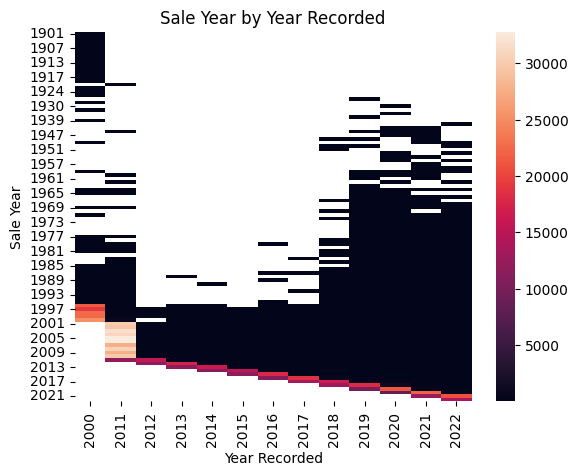

In [64]:
ax = sns.heatmap(saleyr_yr_df)
ax.set_xlabel("Year Recorded")
ax.set_ylabel("Sale Year")
ax.set_title("Sale Year by Year Recorded")

# Merging with Ownership

In [130]:
ownership_df = pd.read_csv(os.path.join(DATA_PATH, "cobb_digest_final.csv"), dtype={"PARID": object})

/var/folders/bb/g7vlcgfn14ld8_w41331g0dw0000gn/T/ipykernel_43721/3134354550.py:1: DtypeWarning: Columns (8,11,13,14,17,19,29,36,37,38,50,55,56,63,69,70,71,74,75,81) have mixed types. Specify dtype option on import or set low_memory=False.
  ownership_df = pd.read_csv(os.path.join(DATA_PATH, "cobb_digest_final.csv"), dtype={"PARID": object})


In [204]:
sales_df = pd.read_csv(os.path.join(DATA_PATH, f"out/COBB_SALES_FINAL.csv"), dtype={"PARID": object})

/var/folders/bb/g7vlcgfn14ld8_w41331g0dw0000gn/T/ipykernel_43721/2186323780.py:1: DtypeWarning: Columns (1,2,3,4,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_df = pd.read_csv(os.path.join(DATA_PATH, f"out/COBB_SALES_FINAL.csv"), dtype={"PARID": object})


In [205]:
original_size = sales_df.shape[0]

# Take subset that is actually contained in the ownership keys
sales_df = sales_df[(sales_df['SALE_YEAR'] >= 2011) & (sales_df['SALE_YEAR'] <= 2021)]
in_yr_range_size = sales_df.shape[0]

print(f"{in_yr_range_size / original_size * 100}% within the range of 2011 to 2021")

43.511150972850146% within the range of 2011 to 2021


In [206]:
sales_tax_merged = pd.merge(sales_df, ownership_df, how="left", left_on=["PARID", "SALE_YEAR"], right_on=["PARID", "asmt_TAXYR"], suffixes=("_SALES", "_DIGEST"))

In [133]:
sales_tax_merged.to_csv(os.path.join(DATA_PATH, "out/COBB_SALES_TAX_DIGEST_FINAL.csv"), index=False)

# Diagnosing Unmatched

In [207]:
unmerged_df = sales_tax_merged[sales_tax_merged["asmt_TAXYR"].isna()]
merged_df = sales_tax_merged[~sales_tax_merged["asmt_TAXYR"].isna()]

In [208]:
unmerged = unmerged_df.shape[0]
print(f"Unmerged: {unmerged} out of {sales_df.shape[0]}, {unmerged / sales_df.shape[0] * 100}%")

Unmerged: 7133 out of 332802, 2.1433164464155863%


In [210]:
unmerged_pids = pd.Series(unmerged_df["PARID"].unique())
print(f"{unmerged_pids.size} unmerged unique parcelIDs")

5809 unmerged unique parcelIDs


In [211]:
not_present = unmerged_pids[~unmerged_pids.isin(ownership_df["PARID"])]
present = unmerged_pids[unmerged_pids.isin(ownership_df["PARID"])]
print(f"{not_present.size} unmerged parcelIDs not present in digest")
print(f"{present.size} unmerged parcelIDs present in digest")

730 unmerged parcelIDs not present in digest
5079 unmerged parcelIDs present in digest


In [212]:
unmerged_not_present_df = unmerged_df[unmerged_df["PARID"].isin(not_present)]
unmerged_present_df = unmerged_df[unmerged_df["PARID"].isin(present)]

In [214]:
unmerged_present_df["year_before"] = unmerged_present_df["SALE_YEAR"] - 1
unmerged_present_df["year_after"] = unmerged_present_df["SALE_YEAR"] + 1

unmerged_year_status_df = pd.merge(unmerged_present_df, ownership_df[["PARID", "asmt_TAXYR"]], left_on=["PARID", "year_before"], right_on=["PARID", "asmt_TAXYR"], how="left", suffixes=("", "_before"))
unmerged_year_status_df = pd.merge(unmerged_year_status_df, ownership_df[["PARID", "asmt_TAXYR"]], left_on=["PARID", "year_after"], right_on=["PARID", "asmt_TAXYR"], how="left", suffixes=("", "_after"))

/var/folders/bb/g7vlcgfn14ld8_w41331g0dw0000gn/T/ipykernel_43721/1924903443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unmerged_present_df["year_before"] = unmerged_present_df["SALE_YEAR"] - 1
/var/folders/bb/g7vlcgfn14ld8_w41331g0dw0000gn/T/ipykernel_43721/1924903443.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unmerged_present_df["year_after"] = unmerged_present_df["SALE_YEAR"] + 1


In [215]:
before = (~unmerged_year_status_df.asmt_TAXYR_before.isna()).sum()
after = (~unmerged_year_status_df.asmt_TAXYR_after.isna()).sum()
both = ((~unmerged_year_status_df.asmt_TAXYR_before.isna()) & (~unmerged_year_status_df.asmt_TAXYR_after.isna())).sum()

print(f"{before}/{unmerged_present_df.shape[0]} parcels existed before sale\n{after}/{unmerged_present_df.shape[0]} parcels existed after \n{both}/{unmerged_present_df.shape[0]} parcels existed both before and after sale.\n" + 
      f"{unmerged_present_df.shape[0] - max(before, after, both)}/{unmerged_present_df.shape[0]} parcels existed neither before nor after.")

39/6192 parcels existed before sale
5708/6192 parcels existed after 
0/6192 parcels existed both before and after sale.
484/6192 parcels existed neither before nor after.


In [216]:
unmerged_present_df.to_csv(os.path.join(DATA_PATH, "out/COBB_UNMERGED_PRESENT.csv"), index=False)
unmerged_not_present_df.to_csv(os.path.join(DATA_PATH, "out/COBB_UNMERGED_NOT_PRESENT.csv"), index=False)